# Market agent: findings so far

Goal: predict short-term (5-hour) stock moves from price data and news, and later let an LLM agent use those predictions for paper trading.

This notebook walks through what has been built and tested so far. The data collection and modelling code lives in `src/`; this notebook only calls it and shows the results.

> **Note:** the outputs below come from exploratory runs on the university GPU server, done over several sessions while the code was still in one notebook. Re-run top to bottom to regenerate everything from the current `src/` code.

In [ ]:
import sys
sys.path.append("..")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DB_PATH

## 1. Price data

Hourly bars for 15 large US stocks from 2016 onwards, downloaded from Alpaca (`src/fetch_prices.py`) and stored in a DuckDB database.

In [ ]:
con = duckdb.connect(str(DB_PATH), read_only=True)
all_data = con.execute("SELECT * FROM price_bars").df()
print(all_data.shape)
print(all_data.head())

(322332, 9)
  symbol                 timestamp   open   high    low  close      volume  \
0   AAPL 2016-01-04 14:00:00+01:00  23.23  23.29  23.12  23.16   1515540.0   
1   AAPL 2016-01-04 15:00:00+01:00  23.16  23.32  22.94  23.09  44294676.0   
2   AAPL 2016-01-04 16:00:00+01:00  23.09  23.37  23.02  23.24  37702216.0   
3   AAPL 2016-01-04 17:00:00+01:00  23.23  23.36  23.05  23.35  25057300.0   
4   AAPL 2016-01-04 18:00:00+01:00  23.35  23.59  23.32  23.56  28606624.0   

   trade_count       vwap  
0       1534.0  23.191619  
1      61032.0  23.106862  
2      66426.0  23.195042  
3      45783.0  23.240167  
4      38645.0  23.426922  


In [ ]:
print(con.execute("SELECT DISTINCT symbol FROM price_bars").df())
con.close()

   symbol
0       V
1     WMT
2     JNJ
3   GOOGL
4      KO
5    MSFT
6    META
7    NVDA
8     XOM
9    AMZN
10   AAPL
11    DIS
12    JPM
13   TSLA
14     PG


Pre- and after-market hours have very little volume, so only the regular session (13:00-20:00 UTC) is kept. `load_prices()` returns the same table with timestamps converted to UTC.

In [ ]:
from src.fetch_prices import load_prices
from src.features import filter_market_hours, add_technical_features, add_time_and_regime, add_target

prices = load_prices()
data = filter_market_hours(prices)
print(data.shape)
print(data["timestamp"].dt.hour.value_counts().sort_index())

(257972, 9)
timestamp
14    15888
15    40392
16    40358
17    40352
18    40338
19    40337
20    40307
Name: count, dtype: int64


### Features

Per stock: last hour's return and the 3 before it, price relative to its 10- and 50-hour moving average, RSI, 10-hour volatility and volume relative to its 20-hour average.

In [ ]:
data = add_technical_features(data)
print(data.shape)

(257237, 18)


In [ ]:
data = add_time_and_regime(data)
print(data.shape)

(257237, 21)


### Target

`target = 1` if the price rises more than 0.14% over the next 5 hours. The classes are close to balanced.

In [ ]:
data = add_target(data)
print(data.shape)
print(data["target"].value_counts(normalize=True))

(257162, 23)
target
0    0.530086
1    0.469914
Name: proportion, dtype: float64


## 2. Exploring the features

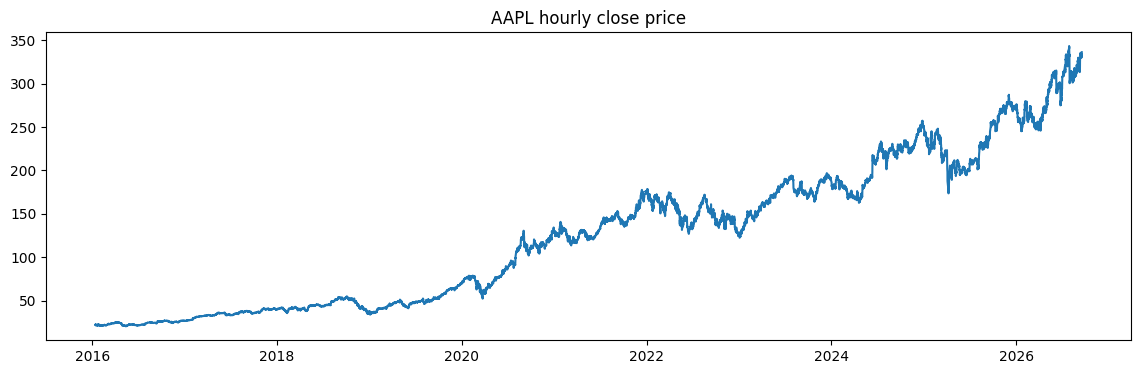

In [ ]:
sample = data[data["symbol"] == "AAPL"]
plt.figure(figsize=(14, 4))
plt.plot(sample["timestamp"], sample["close"])
plt.title("AAPL hourly close price")
plt.show()

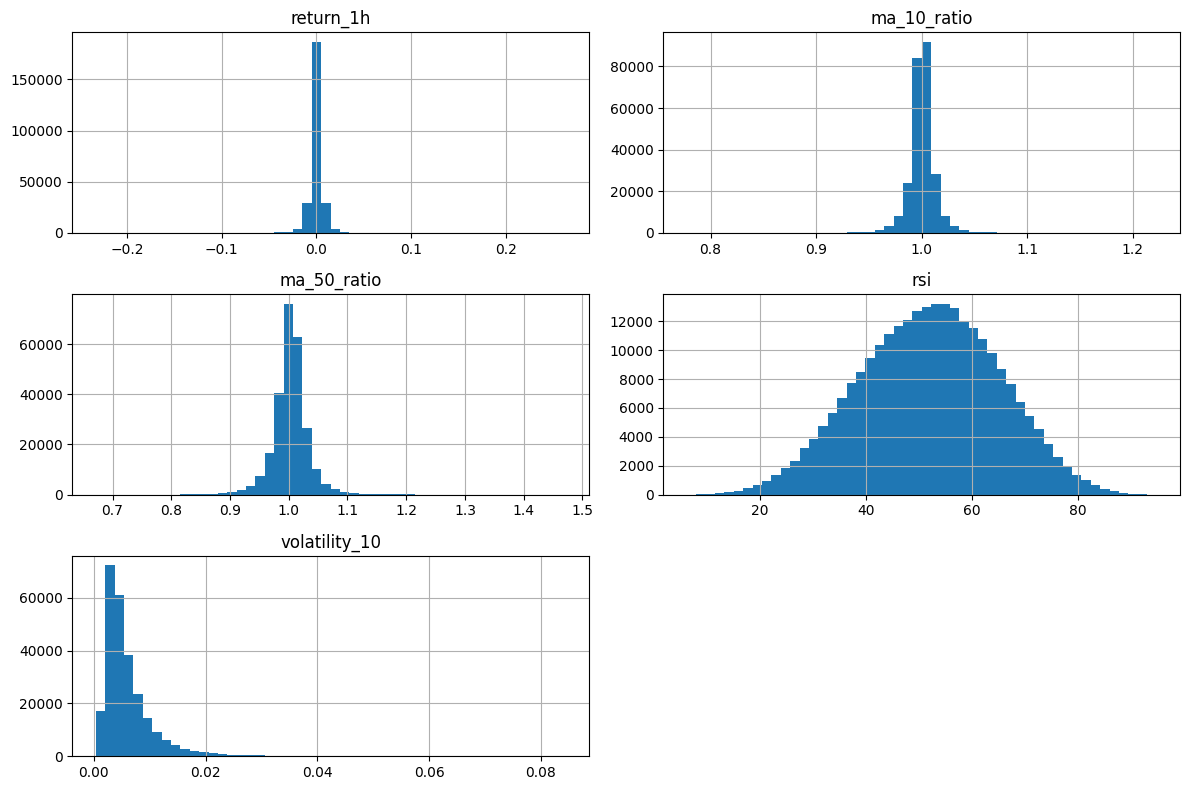

In [ ]:
features = ["return_1h", "ma_10_ratio", "ma_50_ratio", "rsi", "volatility_10"]
data[features].hist(figsize=(12, 8), bins=50)
plt.tight_layout()
plt.show()

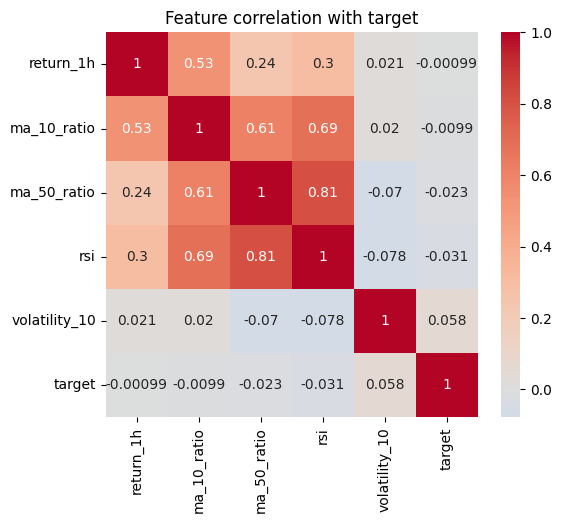

In [ ]:
corr = data[features + ["target"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation with target")
plt.show()

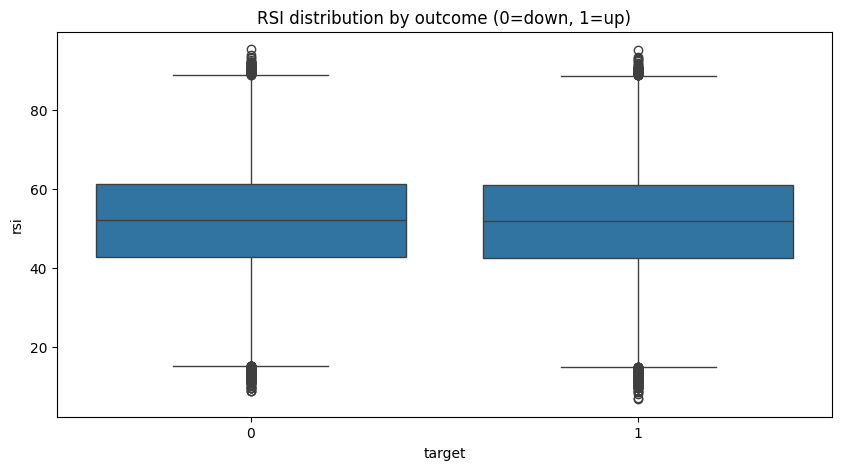

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="target", y="rsi")
plt.title("RSI distribution by outcome (0 = down, 1 = up)")
plt.show()

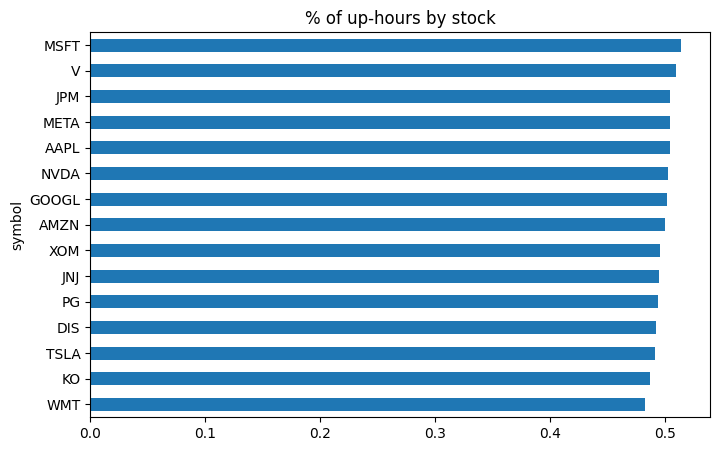

In [ ]:
data.groupby("symbol")["target"].mean().sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("% of up-moves by stock")
plt.show()

Every feature has a correlation close to zero with the target. That is expected for hourly stock returns, and it sets the bar for the model: anything clearly above chance would be surprising.

## 3. Baseline model (price features only)

LightGBM classifier. The data is split by date, never randomly, so the model is always tested on a later period than it was trained on.

In [ ]:
from src.train import FEATURES, time_split, train_model, evaluate

train, val, test = time_split(data)
print("train:", len(train), "val:", len(val), "test:", len(test))

train: 63996 val: 16469 test: 56813


In [ ]:
model = train_model(train)
val_probs, val_preds = evaluate(model, val)

AUC: 0.5392090842904727
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      9779
           1       0.44      0.35      0.39      6690

    accuracy                           0.55     16469
   macro avg       0.52      0.52      0.52     16469
weighted avg       0.54      0.55      0.54     16469

low 0.5294266739262607
mid 0.5198805719137155
high 0.5309173648211106


In [ ]:
print(pd.Series(val_preds).value_counts())

0    11070
1     5399
Name: count, dtype: int64


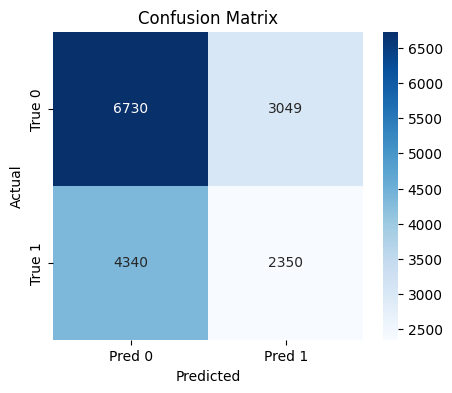

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val["target"], val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion matrix")
plt.show()

**AUC 0.54**: slightly better than a coin flip (0.50), and about the same in calm and volatile markets. The model leans towards predicting "not up".

### Which features does the model rely on? (SHAP)

These plots were made in a later session, so they may not match the exact numbers above.

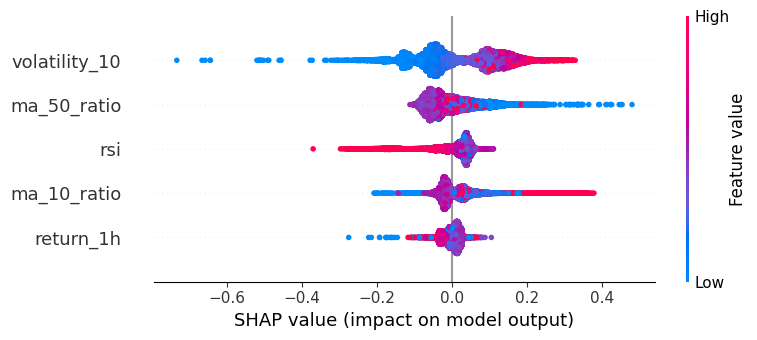

In [ ]:
import shap

X_val = val[FEATURES]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

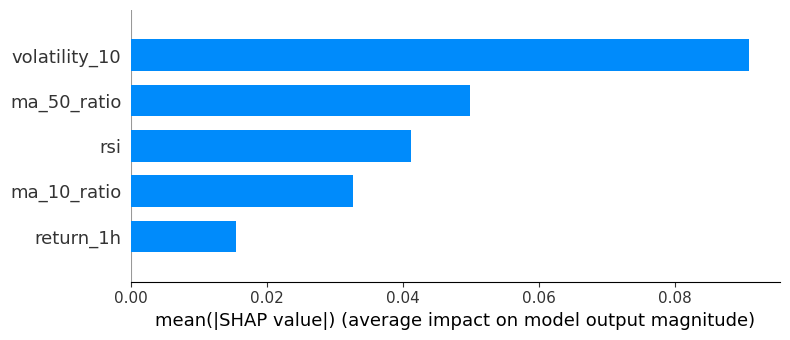

In [ ]:
shap.summary_plot(shap_values, X_val, plot_type="bar")

## 4. News data

News headlines with a per-stock sentiment score from the Alpha Vantage `NEWS_SENTIMENT` API (`src/fetch_news.py`), 2016-2025.

The free plan allows 25 requests per day and returns at most 1000 articles per request. The script therefore saves its progress and continues the next day, and splits any period that hits the 1000-article cap into halves. Part of the collection log:

```
XOM 2025 H1: 349 articles (1/16)
XOM 2025 H2: 1000 articles -- CAPPED, splitting into quarters
  XOM 2025 Q3: 256 articles (3/16)
  XOM 2025 Q4: 1000 articles (4/16)
KO 2025 H1: 189 articles (5/16)
...
JPM 2024 H2: 570 articles (10/16)
Stopping -- rate limit hit.
```

In [ ]:
from src.fetch_news import load_news

news = load_news()
print(news["ticker"].value_counts())
print(prices["symbol"].unique())

ticker
AMZN     7449
MSFT     6745
JPM      6641
AAPL     5650
NVDA     4621
GOOGL    4430
TSLA     4380
META     2541
V        1855
JNJ       128
Name: count, dtype: int64
['AAPL' 'AMZN' 'DIS' 'GOOGL' 'JNJ' 'JPM' 'KO' 'META' 'MSFT' 'NVDA' 'PG'
 'TSLA' 'V' 'WMT' 'XOM']


## 5. Does news sentiment predict the price?

Positive and negative news are weighted differently and summed over time. On a few charts, like the one below, the result seemed to follow the price.

AAPL: 1430 positive, 368 negative articles (relevance > 0.5)


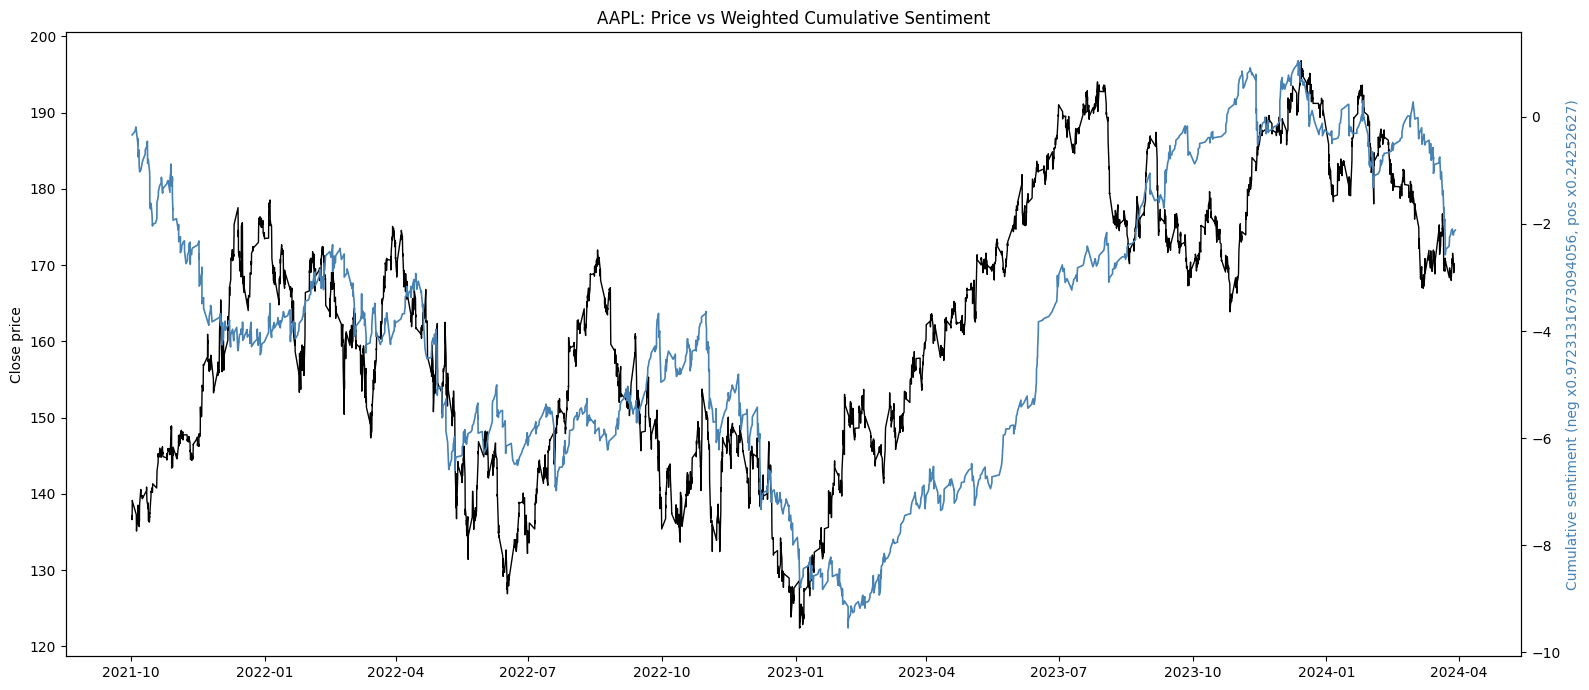

In [ ]:
from src.plots import plot_price_vs_cumulative_sentiment

plot_price_vs_cumulative_sentiment("AAPL", "2021-10-01", "2024-04-01", prices, news)

A few good-looking charts prove nothing, so the same fixed weights were tested on **every** stock with enough news: the correlation between the sentiment in an hour and the return over the next 1-24 hours.

ticker  n_events   corr_1h  n_1h   corr_2h  n_2h   corr_4h  n_4h   corr_8h  n_8h  corr_24h  n_24h
  AAPL      4466  0.078186  2379  0.083169  2379  0.097426  2379  0.087363  2379  0.028706   2379
  AMZN      5257  0.055678  2772  0.073609  2772  0.067390  2772  0.059597  2772  0.077790   2772
 GOOGL      3240  0.034973  1714  0.011105  1714  0.005280  1714  0.015992  1714 -0.014238   1714
   JNJ       111 -0.160375    33 -0.270969    33 -0.342642    33 -0.299141    33 -0.417409     33
   JPM      4695  0.063887  2526  0.025779  2526  0.021201  2526  0.025996  2526 -0.015979   2526
  META      1874  0.036292  1079  0.030209  1079  0.027134  1079  0.014287  1079  0.014285   1079
  MSFT      4520 -0.013429  2342 -0.017770  2342  0.012878  2342  0.022441  2342 -0.002652   2342
  NVDA      2904  0.019843  1562  0.035621  1562  0.061452  1562  0.049480  1562  0.044539   1562
  TSLA      3415  0.010580  1908  0.020895  1908  0.048056  1908  0.019011  1908  0.020591   1908
     V      1312  0.

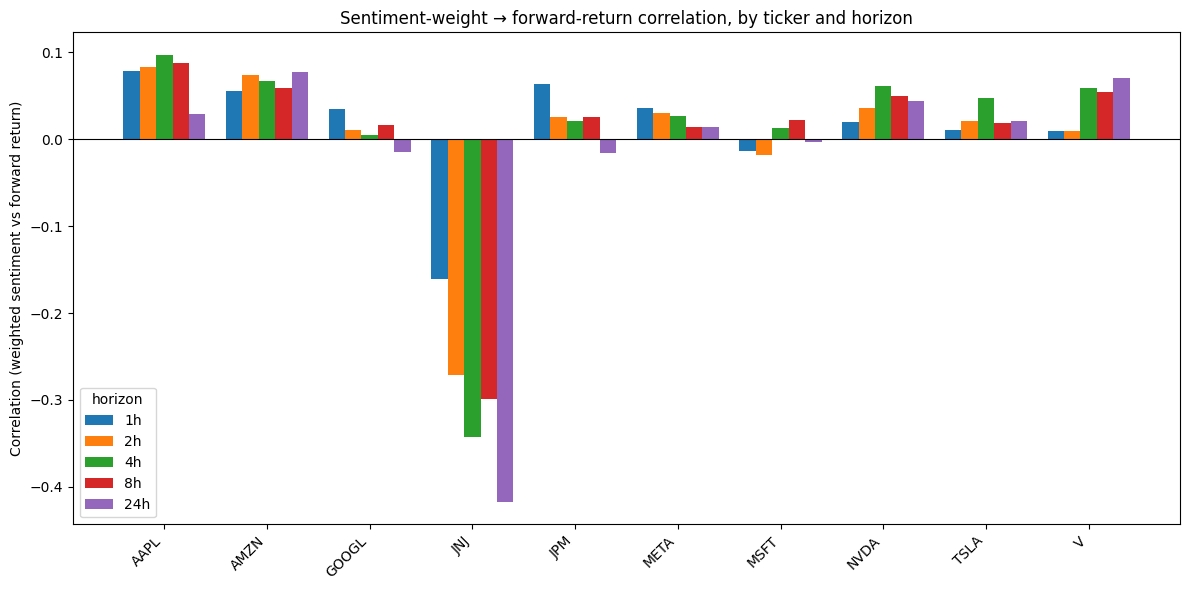

In [ ]:
from src.sentiment_tests import (HORIZONS, run_lag_correlation_test, run_control_tests,
                                 print_summary, print_control_summary, plot_correlation_bars)

tickers = sorted(news["ticker"].unique())
results = run_lag_correlation_test(tickers, news, prices)
pd.set_option("display.width", 150)
print(results.to_string(index=False))
print_summary(results)
plot_correlation_bars(results)

Two control tests check whether the small positive correlations are real:
- **corr_bwd**: sentiment vs. the return that *already happened*. If this is as large as the forward correlation, the news is reacting to the price, not predicting it.
- **corr_cnt**: plain article count vs. forward return. If this is as large, the sentiment score adds nothing beyond "there was news".

In [ ]:
print("=== Control tests: reactivity + does the score beat plain article count? ===")
control = run_control_tests(tickers, news, prices)
print(control.to_string(index=False))
print_control_summary(control)



=== Control tests: reactivity + does the score beat plain article count? ===
ticker  horizon_h  corr_fwd  corr_bwd  corr_cnt
  AAPL          1  0.078186  0.028934  0.009751
  AAPL          2  0.083169  0.055140  0.000761
  AAPL          4  0.097426  0.073732  0.008302
  AAPL          8  0.087363  0.082606 -0.014419
  AAPL         24  0.028706  0.076404 -0.032635
  AMZN          1  0.055678  0.052220  0.001458
  AMZN          2  0.073609  0.073527 -0.000099
  AMZN          4  0.067390  0.068543  0.002909
  AMZN          8  0.059597  0.067785  0.005966
  AMZN         24  0.077790  0.050390  0.008953
 GOOGL          1  0.034973 -0.014646 -0.042951
 GOOGL          2  0.011105 -0.002046 -0.011128
 GOOGL          4  0.005280  0.019609 -0.012929
 GOOGL          8  0.015992  0.048185  0.001099
 GOOGL         24 -0.014238  0.018852  0.021010
   JNJ          1 -0.160375 -0.020637  0.025846
   JNJ          2 -0.270969  0.119229  0.311824
   JNJ          4 -0.342642  0.147560  0.252180
   JNJ   

The mean forward correlation is about 0 at every horizon, while the backward correlation is clearly larger (0.05-0.10). **The news mostly reacts to price moves that already happened.**

### Same test with FinBERT

Alpha Vantage does not explain how its score is made, so the same headlines were scored with FinBERT, an open model (`src/finbert_scores.py`).

In [ ]:
from src.finbert_scores import build_news_finbert

news_finbert = build_news_finbert(news)

In [ ]:
tickers_fb = sorted(news_finbert["ticker"].unique())

results_fb = run_lag_correlation_test(tickers_fb, news_finbert, prices)
print(results_fb.to_string(index=False))

control_fb = run_control_tests(tickers_fb, news_finbert, prices)
print(control_fb.to_string(index=False))
for h in HORIZONS:
    sub = control_fb[control_fb["horizon_h"] == h]
    f, b, c = sub["corr_fwd"].mean(), sub["corr_bwd"].mean(), sub["corr_cnt"].mean()
    print(f"{h}h: fwd={f:.4f} bwd={b:.4f} cnt={c:.4f}")

ticker  n_events   corr_1h  n_1h   corr_2h  n_2h   corr_4h  n_4h   corr_8h  n_8h  corr_24h  n_24h
  AAPL      4466  0.044016  2379  0.040443  2379  0.055742  2379  0.049748  2379  0.019013   2379
  AMZN      5257  0.023889  2772  0.037575  2772  0.045515  2772  0.012653  2772  0.048999   2772
 GOOGL      3240  0.027277  1714  0.033163  1714  0.054195  1714  0.036686  1714  0.031901   1714
  META      1874 -0.007060  1079 -0.034586  1079 -0.035472  1079 -0.001019  1079 -0.011228   1079
  MSFT      4520  0.019417  2342  0.004872  2342  0.019249  2342  0.014290  2342  0.008457   2342
  NVDA      2904 -0.007064  1562  0.011656  1562  0.028126  1562  0.049438  1562  0.046563   1562
  TSLA      1401  0.065733   727  0.079453   727  0.107670   727  0.083694   727  0.103087    727
ticker  horizon_h  corr_fwd  corr_bwd  corr_cnt
  AAPL          1  0.044016 -0.005278  0.009751
  AAPL          2  0.040443  0.017318  0.000761
  AAPL          4  0.055742  0.034774  0.008302
  AAPL          8  0.049

FinBERT gives a slightly higher forward correlation (0.02-0.04), but the backward one is still larger at most horizons.

### Sentiment as an extra model feature

In [ ]:
from src.sentiment_feature_test import run_sentiment_feature_test

USE_WEIGHTED_FORMULA = False   # raw FinBERT score
data_fb = run_sentiment_feature_test(tickers_fb, news_finbert, prices)

Tickers used: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
train: 37511  val: 9296

=== BASELINE (price/technical only) ===
AUC: 0.5152
              precision    recall  f1-score   support

           0       0.57      0.62      0.60      5292
           1       0.44      0.39      0.41      4004

    accuracy                           0.52      9296
   macro avg       0.51      0.51      0.51      9296
weighted avg       0.52      0.52      0.52      9296


=== WITH SENTIMENT FEATURE ===
AUC: 0.5145
              precision    recall  f1-score   support

           0       0.58      0.62      0.60      5292
           1       0.44      0.40      0.42      4004

    accuracy                           0.52      9296
   macro avg       0.51      0.51      0.51      9296
weighted avg       0.52      0.52      0.52      9296

sentiment_feature importance: 170 (out of total 1317, rank 2/11)

AUC change from adding sentiment: -0.0007


In [ ]:
USE_WEIGHTED_FORMULA = True    # positive/negative weighting
print(f"Using {'WEIGHTED formula' if USE_WEIGHTED_FORMULA else 'RAW (unweighted) score'} for sentiment_feature\n")
data_fb_weighted = run_sentiment_feature_test(tickers_fb, news_finbert, prices)

Using WEIGHTED formula for sentiment_feature

Tickers used: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
train: 37511  val: 9296

=== BASELINE (price/technical only) ===
AUC: 0.5152
              precision    recall  f1-score   support

           0       0.57      0.62      0.60      5292
           1       0.44      0.39      0.41      4004

    accuracy                           0.52      9296
   macro avg       0.51      0.51      0.51      9296
weighted avg       0.52      0.52      0.52      9296


=== WITH SENTIMENT FEATURE ===
AUC: 0.5145
              precision    recall  f1-score   support

           0       0.58      0.62      0.60      5292
           1       0.44      0.40      0.42      4004

    accuracy                           0.52      9296
   macro avg       0.51      0.51      0.51      9296
weighted avg       0.52      0.52      0.52      9296

sentiment_feature importance: 170 (out of total 1317, rank 2/11)

AUC change from adding sentiment: -0.0007

The model uses the sentiment feature a lot (2nd most important), but the AUC does not improve (0.5152 to 0.5145). It fits noise in the sentiment rather than learning something useful.

### Looking at individual cases

Price move and sentiment on the same -1 to 1 scale:

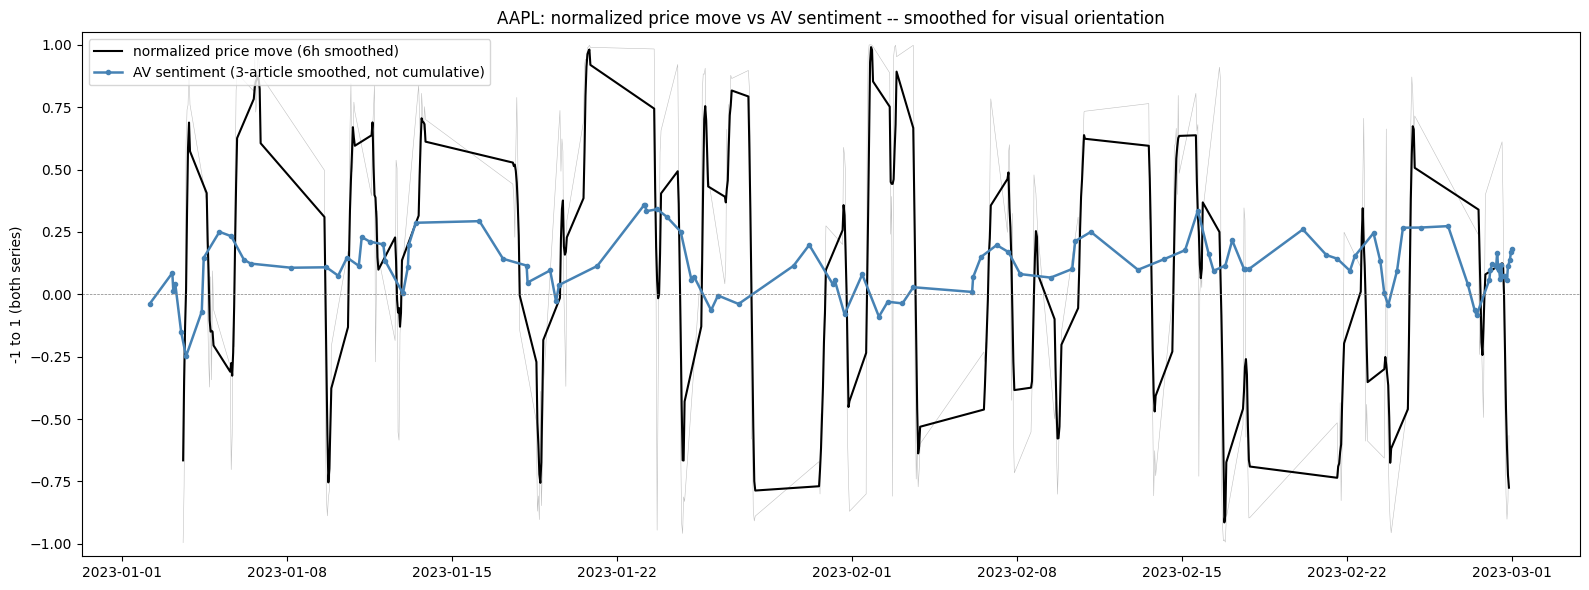

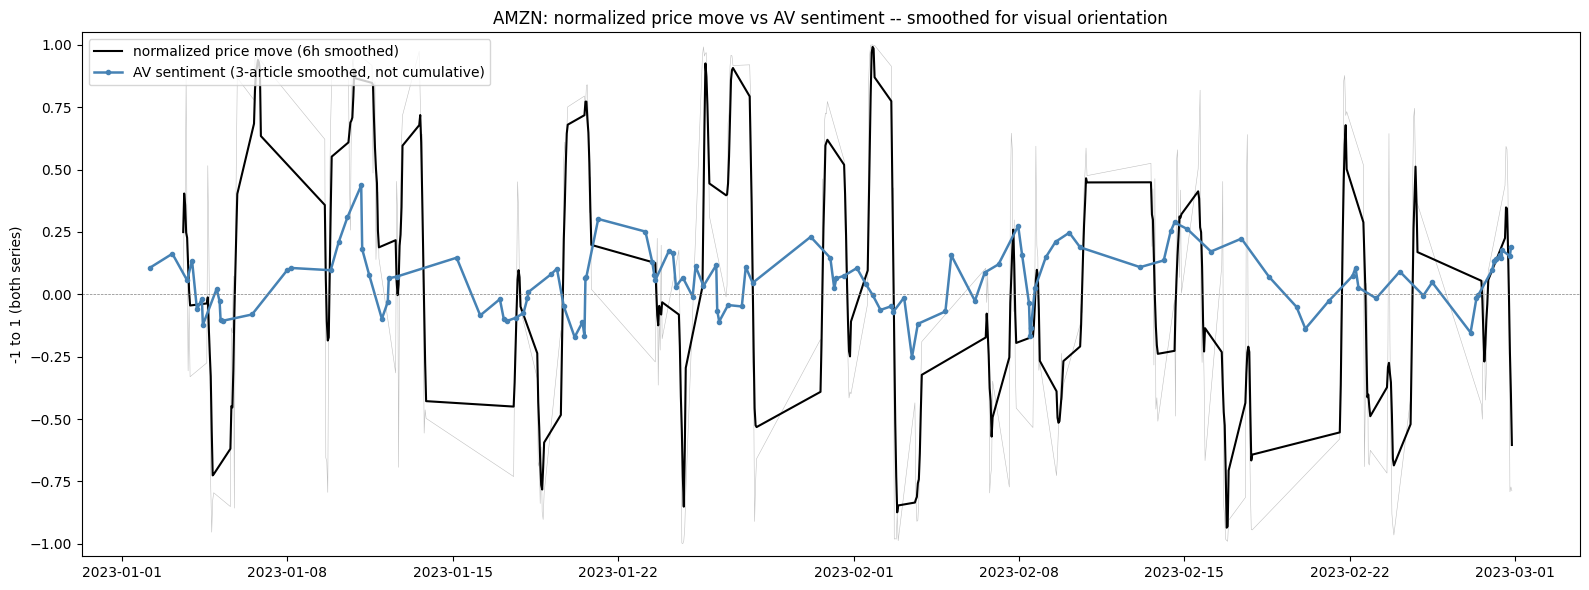

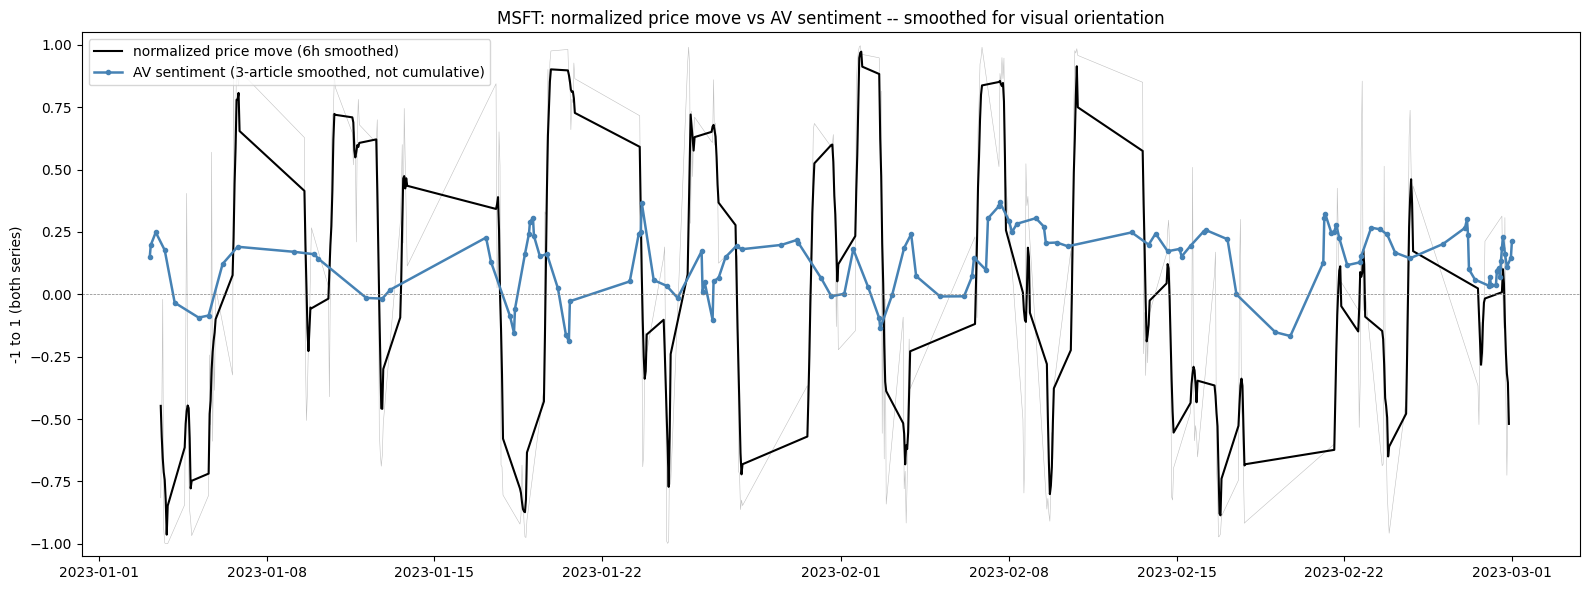

In [ ]:
from src.plots import plot_dual_normalized, find_divergences

for ticker in ["AAPL", "AMZN", "MSFT"]:
    plot_dual_normalized(ticker, "2023-01-01", "2023-03-01", news, prices)

Big price moves where the news pointed the other way, with the headline behind each one:

In [ ]:
for ticker in ["AAPL", "AMZN", "MSFT"]:
    find_divergences(ticker, news, prices, "2021-10-01", "2024-04-01", top_n=10)


=== AAPL: top 10 divergence cases ===
          timestamp                       direction  move_norm  avg_sentiment  n_articles                                                                                            top_headline
2023-06-30 22:00:00 PRICE DOWN / sentiment POSITIVE  -0.724215       0.811600           1                                                          Apple Is the World’s First $3 Trillion Company
2023-05-22 18:00:00 PRICE DOWN / sentiment POSITIVE  -0.771982       0.749347           1                                                          Steve Jobs: Apple Cofounder and Tech Innovator
2022-11-07 17:00:00   PRICE UP / sentiment NEGATIVE   0.856923      -0.648064           1                                 Apple warns of lower iPhone shipments as COVID curbs hobble China plant
2024-02-22 21:00:00 PRICE DOWN / sentiment POSITIVE  -0.778133       0.618984           1   Episode #522: Wes Gray & Robert Elwood on How to Convert a Separately Managed Account (SMA) t

Many of the strongest "positive" scores come from headlines that say nothing about the next few hours ("Steve Jobs: Apple Cofounder and Tech Innovator", a podcast episode, a regional partnership). The relevance filter lets these through.

## 6. Conclusions and next steps

**So far:**
- Price features alone give an AUC of about 0.54: a weak signal.
- News sentiment, from Alpha Vantage or FinBERT, does not improve that. Most of the correlation comes from news reacting to price moves that already happened.

**Next:**
- Filter news better: only headlines about events (earnings, guidance, lawsuits, product launches), not general mentions.
- Evaluate once on the held-out test period (from May 2024), which has not been used yet.
- Build the LLM agent that reads the model's prediction plus current headlines and decides on paper trades through Alpaca, logging its reasoning so every decision can be checked.